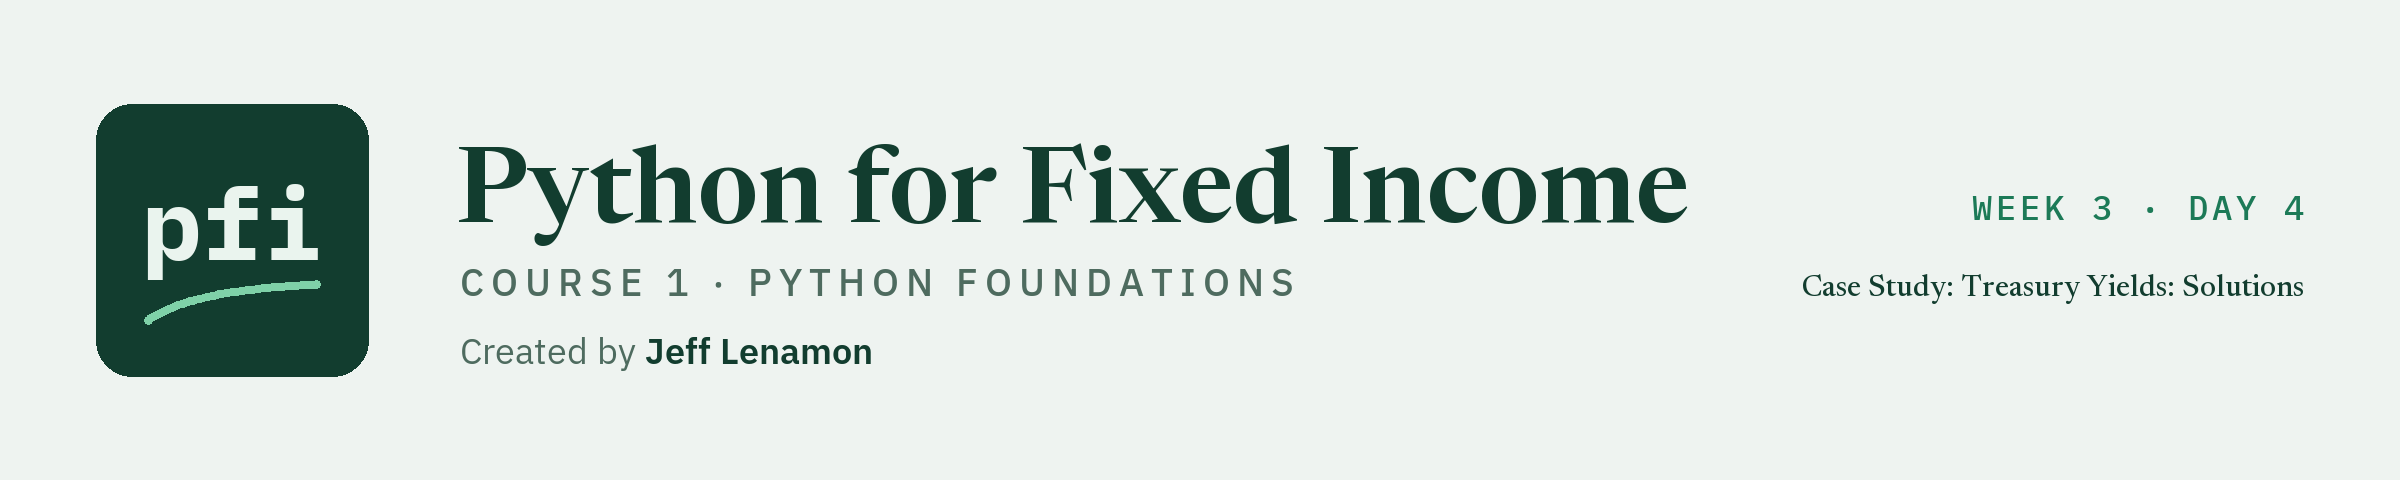

# Case Study: Treasury Yields - Solutions

Week 3. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week3/day4/14_case_study_treasury_yields_solutions.ipynb)

## Exercises

The exercises use the same file and ask about tenors and pairs the lesson did not examine: the `5 Yr`, the `30 Yr`, and the `10 Yr` against the `3 Mo`. The figures are U.S. Treasury par yields as published, retrieved 2026-10-03. Every answer describes the data. None is a view, and none explains a move.

Replace each `...` with your own code, then run the check cell. Exercise 5 asks for a function. Print the numbers you rely on, say the unit, and where an exercise asks for a chart, give it a title and axis labels with units. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports the libraries, defines `check`, a small function that marks your answers, and loads a fresh `yields` with the dates as the index. It prints the shape, (2940, 14), and the first and last date, 2015-01-02 to 2026-10-02.

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    # ... is the placeholder, and None is what a function returns before its body is written
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# a fresh copy of the file, with the dates as the index. In Colab it is read from GitHub.
if os.path.exists('../../../data/treasury_par_yields.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

yields = pd.read_csv(data_folder + 'treasury_par_yields.csv', parse_dates=['date'], index_col='date')

print(yields.shape)
print(yields.index.min().date(), 'to', yields.index.max().date())

(2940, 14)
2015-01-02 to 2026-10-02


### Exercise 1

Q. What was the `5 Yr` yield on 2022-06-15? How many rows does the file have for 2022, and what was the mean `5 Yr` yield in 2022, rounded to 2 decimal places? Store the answers in **ex1_yield**, **ex1_rows**, and **ex1_mean**.

In [2]:
# one cell: a row label and a column label
ex1_yield = yields.loc['2022-06-15', '5 Yr']

# a year alone selects every row of that year
year_2022 = yields.loc['2022']
ex1_rows = len(year_2022)
ex1_mean = round(year_2022['5 Yr'].mean(), 2)

print('5 Yr on 2022-06-15:', ex1_yield, 'percent')
print('Rows in 2022:', ex1_rows)
print('Mean 5 Yr in 2022:', ex1_mean, 'percent')
print('Lowest and highest 5 Yr in 2022:', year_2022['5 Yr'].min(), 'and', year_2022['5 Yr'].max(), 'percent')

5 Yr on 2022-06-15: 3.38 percent
Rows in 2022: 249
Mean 5 Yr in 2022: 3.0 percent
Lowest and highest 5 Yr in 2022: 1.37 and 4.45 percent


* The `5 Yr` was 3.38 percent on 2022-06-15. The file has 249 rows for 2022, and the mean `5 Yr` yield over them was 3.0 percent.
* Within 2022 the `5 Yr` ran from 1.37 to 4.45 percent.
* `yields.loc['2022']` works because the index is a `DatetimeIndex`. The check cell read the file with `parse_dates` and `index_col`.

In [3]:
check('Exercise 1 yield', ex1_yield, 3.38)
check('Exercise 1 rows', ex1_rows, 249)
check('Exercise 1 mean', ex1_mean, 3.0)

Exercise 1 yield: correct
Exercise 1 rows: correct
Exercise 1 mean: correct


### Exercise 2

Q. For the `30 Yr`, work out the mean, lowest, and highest yield in each year, and the range of each year in basis points. In which year was the range widest, and how many basis points was it? Store the answers in **ex2_year** and **ex2_range_bp**.

In [4]:
# three statistics of the 30 Yr for each year
by_year = yields.groupby(yields.index.year)['30 Yr'].agg(['mean', 'min', 'max'])
by_year.index.name = 'year'

# highest less lowest, in percent, times 100 for basis points
by_year['range_bp'] = ((by_year['max'] - by_year['min']) * 100).round().astype(int)
print(by_year.round(2))

# idxmax() returns the row label, here the year, of the widest range
ex2_year = by_year['range_bp'].idxmax()
ex2_range_bp = by_year['range_bp'].max()

print('Widest range:', ex2_range_bp, 'basis points, in', ex2_year)
print('Narrowest range:', by_year['range_bp'].min(), 'basis points, in', by_year['range_bp'].idxmin())

      mean   min   max  range_bp
year                            
2015  2.84  2.25  3.25       100
2016  2.59  2.11  3.19       108
2017  2.89  2.66  3.20        54
2018  3.11  2.78  3.46        68
2019  2.58  1.94  3.13       119
2020  1.56  0.99  2.38       139
2021  2.06  1.66  2.45        79
2022  3.11  2.01  4.40       239
2023  4.09  3.54  5.11       157
2024  4.41  3.94  4.82        88
2025  4.78  4.41  5.08        67
2026  5.01  4.64  5.64       100
Widest range: 239 basis points, in 2022
Narrowest range: 54 basis points, in 2017


* The widest range of the `30 Yr` within one year was 239 basis points, in 2022, from 2.01 to 4.40 percent. The narrowest was 54 basis points, in 2017.
* The `30 Yr` yearly mean was lowest in 2020, 1.56 percent, and highest in the part year 2026, 5.01 percent. Among whole years the highest is 2025, 4.78 percent.
* The `10 Yr` in the lesson had its widest and narrowest years in 2022 and 2017 as well, at 262 and 57 basis points.
* 2026 covers 2 January to 2 October. Its range, 100 basis points, is for a part year.

In [5]:
check('Exercise 2 year', ex2_year, 2022)
check('Exercise 2 range', ex2_range_bp, 239)

Exercise 2 year: correct
Exercise 2 range: correct


### Exercise 3

Q. Work out the `10 Yr` yield less the `3 Mo` yield for every date, in whole basis points. On how many days was it below zero? Which year had the most such days? Store the answers in **ex3_days** and **ex3_year**. Draw the spread over time with a reference line at zero.

date
2015      0
2016      0
2017      0
2018      0
2019    104
2020     13
2021      0
2022     47
2023    250
2024    238
2025     86
2026      0
dtype: int64
Days below zero: 738 of 2940
Year with the most: 2023 with 250 of 250 rows
First day below zero: 2019-03-22  last: 2025-10-16
Lowest: -189 first on 2023-05-04  highest: 248 on 2015-06-10


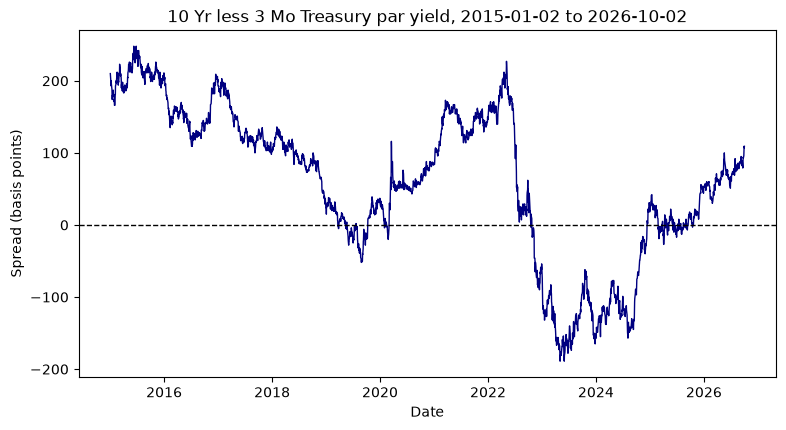

In [6]:
# the difference in percent, times 100 for basis points, as whole numbers
spread = ((yields['10 Yr'] - yields['3 Mo']) * 100).round().astype(int)

below = spread < 0
ex3_days = below.sum()

# the days below zero in each year
below_by_year = below.groupby(yields.index.year).sum()
print(below_by_year)
ex3_year = below_by_year.idxmax()

print('Days below zero:', ex3_days, 'of', len(spread))
print('Year with the most:', ex3_year, 'with', below_by_year.max(), 'of', len(yields.loc[str(ex3_year)]), 'rows')
print('First day below zero:', spread.index[below].min().date(), ' last:', spread.index[below].max().date())
print('Lowest:', spread.min(), 'first on', spread.idxmin().date(), ' highest:', spread.max(), 'on', spread.idxmax().date())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(spread.index, spread, linewidth=1, color='navy')
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('10 Yr less 3 Mo Treasury par yield, 2015-01-02 to 2026-10-02')
ax.set_xlabel('Date')
ax.set_ylabel('Spread (basis points)')
plt.show()

* The `10 Yr` less `3 Mo` spread was below zero on 738 of the 2,940 days. 2023 had the most, 250, which is every row of that year. 2024 had 238, 2019 had 104, 2025 had 86, 2022 had 47, and 2020 had 13.
* The first day below zero was 2019-03-22 and the last was 2025-10-16.
* The lowest value was -189 basis points, first on 2023-05-04, and the highest was 248, on 2015-06-10.
* The `10 Yr` less `2 Yr` spread of the lesson was below zero on 544 days, in four years. This pair was below zero on more days, in six years. Which two tenors are meant has to be said whenever a curve spread is quoted.

In [7]:
check('Exercise 3 days', ex3_days, 738)
check('Exercise 3 year', ex3_year, 2023)

Exercise 3 days: correct
Exercise 3 year: correct


### Exercise 4

Q. Work out the daily change of the `5 Yr` yield in basis points. What was the largest one-day rise and on which date? What was the largest one-day fall and on which date? Store the two changes in **ex4_rise** and **ex4_fall**, and the two dates as text such as `'2020-03-09'` in **ex4_rise_date** and **ex4_fall_date**. A date becomes text with `.strftime('%Y-%m-%d')`. Draw the histogram of the daily changes.

Largest rise: 31.0 basis points on 2022-06-13
Largest fall: -32.0 basis points on 2022-11-10
Standard deviation: 5.53 basis points
Days within 5 basis points of zero: 2222 of 2939
date
2022-06-13    31.0
2024-04-10    24.0
2022-08-05    21.0
Name: 5 Yr, dtype: float64
date
2022-11-10   -32.0
2022-09-28   -29.0
2023-03-13   -28.0
Name: 5 Yr, dtype: float64


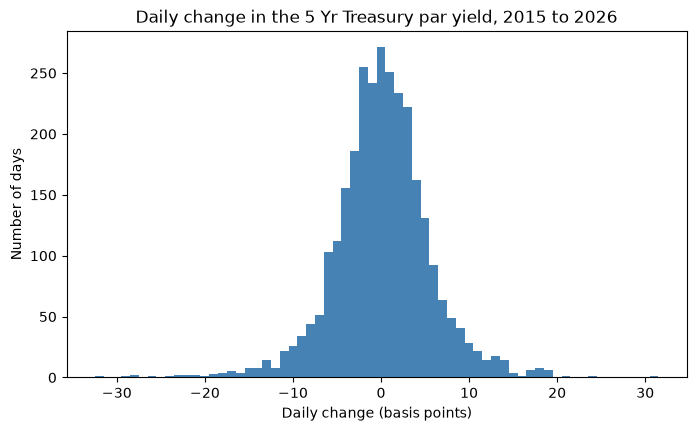

In [8]:
# each row less the row before, times 100 for basis points
changes = (yields['5 Yr'].diff() * 100).round()

ex4_rise = changes.max()
ex4_fall = changes.min()

# idxmax() and idxmin() return the dates. strftime() writes a date as text in the layout given.
ex4_rise_date = changes.idxmax().strftime('%Y-%m-%d')
ex4_fall_date = changes.idxmin().strftime('%Y-%m-%d')

print('Largest rise:', ex4_rise, 'basis points on', ex4_rise_date)
print('Largest fall:', ex4_fall, 'basis points on', ex4_fall_date)
print('Standard deviation:', round(changes.std(), 2), 'basis points')
print('Days within 5 basis points of zero:', (changes.abs() <= 5).sum(), 'of', changes.count())

# the three largest moves each way, with their dates
print(changes.nlargest(3))
print(changes.nsmallest(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
# one bar per basis point, centred on the whole number
edges = [value - 0.5 for value in range(-32, 33)]
ax.hist(changes.dropna(), bins=edges, color='steelblue')
ax.set_title('Daily change in the 5 Yr Treasury par yield, 2015 to 2026')
ax.set_xlabel('Daily change (basis points)')
ax.set_ylabel('Number of days')
plt.show()

* The largest one-day rise in the `5 Yr` was 31 basis points on 2022-06-13, and the largest one-day fall was -32 basis points on 2022-11-10.
* Those are two of the dates in the lesson's table for the `10 Yr`, which rose 28 basis points on 2022-06-13 and fell 30 on 2022-11-10.
* The standard deviation of the `5 Yr` daily change is 5.53 basis points, and 2,222 of the 2,939 changes were within 5 basis points of zero.
* `changes.count()` is 2,939 and not 2,940, because the first row has no row before it.

In [9]:
check('Exercise 4 largest rise', ex4_rise, 31.0)
check('Exercise 4 date of the rise', ex4_rise_date, '2022-06-13')
check('Exercise 4 largest fall', ex4_fall, -32.0)
check('Exercise 4 date of the fall', ex4_fall_date, '2022-11-10')

Exercise 4 largest rise: correct
Exercise 4 date of the rise: correct
Exercise 4 largest fall: correct
Exercise 4 date of the fall: correct


### Exercise 5

The lesson worked out one curve spread, the `10 Yr` less the `2 Yr`, and exercise 3 worked out another. The arithmetic is the same for any two tenors on any date, which makes it a function.

Q. Write a function that takes the table, the names of two tenors, and a date written as text, and returns the first tenor's yield less the second's on that date, in whole basis points. Then call it three times: the `10 Yr` less the `2 Yr` on 2026-10-02, the `30 Yr` less the `20 Yr` on 2026-10-02, and the `10 Yr` less the `3 Mo` on 2023-05-04. Store the answers in **ex5_10y_2y**, **ex5_30y_20y**, and **ex5_10y_3m**.

In [10]:
def curve_spread_bp(table, long_tenor, short_tenor, date):
    """Return the long tenor's yield less the short tenor's on one date, in whole basis points."""
    # one row of the table, chosen by its date label
    row = table.loc[date]

    # the difference in percent, times 100 for basis points
    # round() removes the tiny error of decimal arithmetic, and int() makes it a whole number
    return int(round((row[long_tenor] - row[short_tenor]) * 100))


ex5_10y_2y = curve_spread_bp(yields, '10 Yr', '2 Yr', '2026-10-02')
ex5_30y_20y = curve_spread_bp(yields, '30 Yr', '20 Yr', '2026-10-02')
ex5_10y_3m = curve_spread_bp(yields, '10 Yr', '3 Mo', '2023-05-04')

print(f'10 Yr less 2 Yr on 2026-10-02: {ex5_10y_2y} basis points')
print(f'30 Yr less 20 Yr on 2026-10-02: {ex5_30y_20y} basis points')
print(f'10 Yr less 3 Mo on 2023-05-04: {ex5_10y_3m} basis points')

# the levels behind the second answer
print(yields.loc['2026-10-02', ['20 Yr', '30 Yr']].to_dict())

10 Yr less 2 Yr on 2026-10-02: 45 basis points
30 Yr less 20 Yr on 2026-10-02: -4 basis points
10 Yr less 3 Mo on 2023-05-04: -189 basis points
{'20 Yr': 5.67, '30 Yr': 5.63}


* 45 basis points for the `10 Yr` less the `2 Yr` on the last date, the figure the lesson ended section 6.0 with.
* -4 basis points for the `30 Yr` less the `20 Yr` on the same date: the `20 Yr` was 5.67 percent and the `30 Yr` 5.63.
* -189 basis points for the `10 Yr` less the `3 Mo` on 2023-05-04, the lowest value of exercise 3.
* The function returns a number and prints nothing, so each answer can be stored, compared, and put into a sentence with its unit. The unit is in the name, `curve_spread_bp`, so that nobody reads the result as percent.
* A date with no row, such as `'2024-07-04'`, raises a `KeyError` inside the function, as in section 2.3. The function stops, and that is the right behaviour: a spread for a date the file does not have would be an invented number.

In [11]:
check('Exercise 5 10 Yr less 2 Yr', ex5_10y_2y, 45)
check('Exercise 5 30 Yr less 20 Yr', ex5_30y_20y, -4)
check('Exercise 5 10 Yr less 3 Mo', ex5_10y_3m, -189)

Exercise 5 10 Yr less 2 Yr: correct
Exercise 5 30 Yr less 20 Yr: correct
Exercise 5 10 Yr less 3 Mo: correct


### Exercise 6: AI check

You ask an AI assistant for the average `10 Yr` yield in each year of the file. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

Q. Read the code before you run it. How many years should the table have, and what should the 2025 figure be? The lesson worked both out in section 3.2. Then run the code. Does the answer agree with you?

* The lesson's table has 12 years, 2015 to 2026, and a 2025 mean of 4.29 percent. The original code reported 2 years, 2025 and 2026, and a 2025 mean of 4.25 percent, with no error and no warning.
* The bug was the line `data = data.dropna()`, with the comment `remove rows with missing values`. With nothing in the brackets, `dropna()` removes every row that has a blank in any column. The `1.5 Month` tenor is blank on every date before 2025-02-18, so every row before that date was removed: 2,532 of the 2,940.
* The `10 Yr` column has no blanks at all. The rows were removed because of a column the question never asked about.
* Two things give it away. The table has 2 rows where 12 were expected. And the 2025 figure, 4.25, is an average from 18 February to the end of the year, 218 days, where the lesson's 4.29 is an average of all 249. A wrong number that is close to the right one is the harder kind to catch, which is why the count of years matters.
* The fix is to delete the `dropna()` line. If a column with blanks were the one being averaged, the fix would be `dropna(subset=[...])` naming that column, and a `count()` beside the mean.

In [12]:
# load the data
data = pd.read_csv(data_folder + 'treasury_par_yields.csv', parse_dates=['date'], index_col='date')

# no rows are removed: the 10 Yr has a value on every date
print('Rows:', len(data), ' 10 Yr values:', data['10 Yr'].count())

# average 10 Yr yield by year
by_year = data.groupby(data.index.year)['10 Yr'].mean().round(2)
print(by_year)

ex6_years = len(by_year)
ex6_mean_2025 = by_year.loc[2025]

print('Years in the table:', ex6_years)
print('Average 10 Yr yield in 2025:', ex6_mean_2025, 'percent')

Rows: 2940  10 Yr values: 2940
date
2015    2.14
2016    1.84
2017    2.33
2018    2.91
2019    2.14
2020    0.89
2021    1.45
2022    2.95
2023    3.96
2024    4.21
2025    4.29
2026    4.47
Name: 10 Yr, dtype: float64
Years in the table: 12
Average 10 Yr yield in 2025: 4.29 percent


In [13]:
check('Exercise 6 years', ex6_years, 12)
check('Exercise 6 mean for 2025', ex6_mean_2025, 4.29)

Exercise 6 years: correct
Exercise 6 mean for 2025: correct
